In [ ]:
from __future__ import annotations
import math
import re
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from training_pipeline import build_train_val_test_series
from training_pipeline_config import build_model_configs
from imputation_benchmark_pipeline import TSPulseHistoricalImputer, execute_complete_pipeline
from utils import get_longest_segment, load_dataset_paths, load_to_df
# -------------------------------------------------------------------
# Config
# -------------------------------------------------------------------
FREQ = "h"
GAP_SIZES = (1, 2, 5, 10)
NUM_GAPS = 3
HYBRID_RANDOM_FRACTION = 0.75
RANDOM_SEED = 42
SEASONALITY_M = 24
DARTS_MODELS = ["DLinear", "NLinear"]  # añade más si quieres
VAL_SIZE = 10
MIN_TRAIN_LEN = 82
FORCE_END = False  # igual que en tu notebook habitual con get_longest_segment(proc_ds, False)
# -------------------------------------------------------------------
# Rutas (funciona si el notebook está en repo/ o repo/src/)
# -------------------------------------------------------------------
cwd = Path.cwd().resolve()
if (cwd / "src").exists():
    REPO_ROOT = cwd
elif (cwd.parent / "src").exists():
    REPO_ROOT = cwd.parent
else:
    raise RuntimeError("No encuentro la raíz del repo (carpeta src/).")
ARTIFACTS_DIR = REPO_ROOT / "src" / "artifacts" / "models"
OUT_DIR = cwd  # guarda resultados en el directorio del notebook
# -------------------------------------------------------------------
# 1) Carga de series del proyecto + segmentación existente
# -------------------------------------------------------------------
base_path = str((REPO_ROOT / "Datos-post-COUTA" / "*/").resolve())
paths = sorted(load_dataset_paths(base_path=base_path, key_word="NO2", file_extension="csv"))
if not paths:
    raise RuntimeError(f"No se encontraron CSVs en {base_path}")
proc_ds = []
for p in paths:
    df = load_to_df(p, name_from_path=True)
    if df is None or df.empty or len(df.columns) != 1:
        continue
    col = str(df.columns[0])
    s = (
        df.iloc[:, 0]
        .astype(float)
        .sort_index()
        .asfreq(FREQ)
        .interpolate(method="time")
        .ffill()
        .bfill()
    )
    proc_ds.append(s.to_frame(name=col))
if not proc_ds:
    raise RuntimeError("No quedaron series válidas tras cargar y normalizar.")
longest_segment = get_longest_segment(proc_ds, force_end=FORCE_END, verbose=True)
# Este es el pipeline que ya usáis para train/val/test
dataset_bundle = build_train_val_test_series(
    proc_ds,
    longest_segment,
    val_size=VAL_SIZE,
    min_train_len=MIN_TRAIN_LEN,
)
print(f"[data] valid_cols ({len(dataset_bundle['valid_cols'])}): {dataset_bundle['valid_cols']}")
# -------------------------------------------------------------------
# 2) Carga de modelos Darts entrenados
# -------------------------------------------------------------------
def _best_artifact_path(model_name: str) -> Path | None:
    cands = list(ARTIFACTS_DIR.glob(f"{model_name}_k*.pt"))
    if not cands:
        return None
    def score(path: Path) -> int:
        m = re.search(r"_k(\d+)\.pt$", path.name)
        return int(m.group(1)) if m else -1
    return max(cands, key=score)
model_configs = build_model_configs()
model_dict: dict[str, object] = {}
for name in DARTS_MODELS:
    if name not in model_configs:
        print(f"[warn] Modelo no reconocido en config: {name}")
        continue
    model_cls, _ = model_configs[name]
    model_path = _best_artifact_path(name)
    if model_path is None:
        print(f"[warn] No hay artefacto para {name} en {ARTIFACTS_DIR}")
        continue
    print(f"[load] {name}: {model_path}")
    try:
        model = model_cls.load(str(model_path), pl_trainer_kwargs={"accelerator": "cpu"})
    except TypeError:
        model = model_cls.load(str(model_path))
    model_dict[name] = model
# TSPulse
print("[load] TSPulse: ibm-granite/granite-timeseries-tspulse-r1")
model_dict["TSPulse"] = TSPulseHistoricalImputer(
    model_id="ibm-granite/granite-timeseries-tspulse-r1",
    revision="tspulse-hybrid-dualhead-512-p8-r1",
    context_length=512,
    freq=FREQ,
    batch_size=1000,
    local_files_only=False,
)
if not model_dict:
    raise RuntimeError("No se cargó ningún modelo.")
# -------------------------------------------------------------------
# 3) Ejecutar benchmark de imputación con gaps híbridos
# -------------------------------------------------------------------
# all_series: referencia completa para MASE (usa las series originales)
all_series = proc_ds
results_df, predictions, plot_store = execute_complete_pipeline(
    model_dict=model_dict,
    dataset_bundle=dataset_bundle,          # << usa split train/test del pipeline existente
    all_series=all_series,
    gap_sizes=GAP_SIZES,
    num_gaps=NUM_GAPS,
    gap_strategy="hybrid_tspulse",
    hybrid_random_fraction=HYBRID_RANDOM_FRACTION,
    metrics=("mae", "rmse", "mase"),
    random_seed=RANDOM_SEED,
    freq=FREQ,
    seasonality_m=SEASONALITY_M,
)
results_df = results_df.sort_values(["Gap_Size", "Serie", "Modelo"]).reset_index(drop=True)
csv_path = OUT_DIR / "imputation_metrics_hybrid_from_pipeline.csv"
results_df.to_csv(csv_path, index=False)
print(f"[save] CSV: {csv_path}")
print(results_df.to_string(index=False))
print("\n[metrics] Promedio global por modelo:")
print(
    results_df.groupby("Modelo")[["MAE", "RMSE", "MASE"]]
    .mean()
    .sort_values("MAE")
    .to_string()
)
# -------------------------------------------------------------------
# 4) Plot helper: predicciones como PUNTOS (scatter), guardado en disco
# -------------------------------------------------------------------
def _prediction_window(preds_by_model: dict[str, pd.Series]):
    starts, ends = [], []
    for s in preds_by_model.values():
        ps = s.dropna()
        if len(ps) == 0:
            continue
        starts.append(ps.index.min())
        ends.append(ps.index.max())
    if not starts:
        return None
    return min(starts), max(ends)
def _mase_map(df: pd.DataFrame, serie: str, gap: int) -> dict[str, float]:
    sub = df[(df["Serie"] == serie) & (df["Gap_Size"] == int(gap))]
    out = {}
    for _, r in sub.iterrows():
        if pd.notna(r["MASE"]):
            out[str(r["Modelo"])] = float(r["MASE"])
    return out
def save_point_plots_by_gap(plot_store, results_df, out_dir: Path, prefix="plot_points_hybrid_pipeline"):
    gaps = sorted(plot_store.keys())
    series_names = list(plot_store[gaps[0]]["series"].keys())
    saved = []
    n_cols = 2
    for k, serie in enumerate(series_names, start=1):
        n_rows = math.ceil(len(gaps) / n_cols)
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(8*n_cols, 5*n_rows), squeeze=False)
        for i, gap in enumerate(gaps):
            ax = axes[i // n_cols][i % n_cols]
            payload = plot_store[gap]["series"][serie]
            actual = payload["actual"]
            preds = payload["preds"]
            naive = payload.get("naive_mase", pd.Series(dtype=float))
            window = _prediction_window(preds)
            if window is not None:
                start, end = window
                actual_plot = actual.loc[start:end]
                naive_plot = naive.dropna().loc[start:end]
            else:
                actual_plot = actual
                naive_plot = naive.dropna()
            if len(actual_plot) > 0:
                ax.plot(actual_plot.index, actual_plot.values, color="black", alpha=0.4, lw=1.2, label="Real")
            if len(naive_plot) > 0:
                ax.plot(naive_plot.index, naive_plot.values, ls="--", color="orange", lw=1.0, label="Naive y(t-m)")
            mase_by_model = _mase_map(results_df, serie, gap)
            for model_name, pred_s in preds.items():
                ps = pred_s.dropna()
                if len(ps) == 0:
                    continue
                label = f"{model_name} (MASE={mase_by_model.get(model_name, float('nan')):.3f})" if model_name in mase_by_model else model_name
                ax.scatter(ps.index, ps.values, s=24, alpha=0.9, label=label)
            ax.set_title(f"Serie: {serie} | Gap={gap} | Hybrid")
            ax.set_xlabel("Tiempo")
            ax.set_ylabel("NO2")
            ax.legend(loc="upper right", fontsize=8)
        for j in range(len(gaps), n_rows * n_cols):
            axes[j // n_cols][j % n_cols].axis("off")
        fig.tight_layout()
        out_path = out_dir / f"{prefix}_by_gap_{k:02d}.png"
        fig.savefig(out_path, dpi=170, bbox_inches="tight")
        plt.show()
        plt.close(fig)
        saved.append(out_path)
    return saved
saved_plots = save_point_plots_by_gap(plot_store, results_df, OUT_DIR)
print("\n[save] Plots (puntos):")
for p in saved_plots:
    print(" -", p)

Mover la creación de train, val y test fuera del eval para que se puedan usar en otros sitios

In [1]:
import pandas as pd
from utils import load_dataset_paths, load_to_df, get_longest_segment
import os

os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")

'0'

In [2]:
file_paths = load_dataset_paths("../Datos-post-COUTA/*/", key_word="NO2", file_extension="csv")

proc_ds = list() 

for path in file_paths:
    proc_ds.append(load_to_df(path))

In [3]:
longest_segment = get_longest_segment(proc_ds, False)

--- Winning Segment ---
Dimensions: 215 rows x 7 columns
Recovered columns: ['Aquatec - Calle Real', 'AQN1 - Puerto', 'Aquatec - Ramon y Cajal', 'Aquatec - Pintor Balaca', 'Aquatec - Carlos III', 'Aquatec - San Diego', 'AQN2 - San Francisco']
Range: 2024-03-19 15:00:00 to 2024-03-28 13:00:00
Score (Total area): 27.544456535888802
------------------------


In [4]:
from training_pipeline import build_train_val_test_series

/home/daniel/pollution/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.
The StatsForecast module could not be imported. To enable support for the AutoARIMA, AutoETS and Croston models, please consider installing it.


In [5]:
dataset_bundle = build_train_val_test_series(proc_ds, longest_segment)

In [6]:
from training_pipeline import eval_global_methods

In [ ]:
methods_to_run = ["TiDE", "NHiTS", "TCN", "TSMixer", "RNN", "NLinear", "DLinear"]
results, trained_models = eval_global_methods(dataset_bundle, size_k=10, method_names=methods_to_run)

In [8]:
methods_to_run = ["NLinear", "DLinear"]
results, trained_models = eval_global_methods(dataset_bundle, size_k=10, method_names=methods_to_run)

Evaluando NLinear
Epoch 6: 100%|██████████| 4998/4998 [01:46<00:00, 46.77it/s, train_loss=0.323, val_loss=0.346]
Evaluando DLinear
Epoch 5: 100%|██████████| 4998/4998 [01:48<00:00, 46.24it/s, train_loss=0.403, val_loss=0.344]


In [7]:
from pathlib import Path
import pickle

ARTIFACTS_DIR = Path("artifacts")
MODELS_DIR = ARTIFACTS_DIR / "models"
SCALERS_PATH = ARTIFACTS_DIR / "scalers.pkl"

MODELS_DIR.mkdir(parents=True, exist_ok=True)


def save_artifacts(trained_models: dict, dict_scalers: dict, size_k: int):
    for name, model in trained_models.items():
        model_path = MODELS_DIR / f"{name}_k{size_k}.pt"
        model.save(str(model_path))

    with open(SCALERS_PATH, "wb") as f:
        pickle.dump(dict_scalers, f)


def load_model(name: str, size_k: int, model_cls):
    model_path = MODELS_DIR / f"{name}_k{size_k}.pt"
    if not model_path.exists():
        return None
    return model_cls.load(str(model_path), map_location="cpu", pl_trainer_kwargs={"accelerator": "cpu"})


def load_scalers():
    if not SCALERS_PATH.exists():
        return None
    with open(SCALERS_PATH, "rb") as f:
        return pickle.load(f)

In [8]:
from darts.models import (
    DLinearModel,
    NHiTSModel,
    NLinearModel,
    RNNModel,
    TCNModel,
    TSMixerModel,
    TiDEModel,
)

In [9]:
trained_models = dict()
methods_to_run = ["TiDE", "NHiTS", "TCN", "TSMixer", "RNN", "NLinear", "DLinear"]
for name, model in zip(methods_to_run, [TiDEModel, NHiTSModel, TCNModel, TSMixerModel, RNNModel, NLinearModel, DLinearModel]):
    trained_models[name] = load_model(name, 10, model)

In [ ]:
from complete_pipeline import execute_complete_pipeline

ranking_df, scalers_finales, plot_store = execute_complete_pipeline(
    model_dict=trained_models,
    dataset_bundle=dataset_bundle,
    all_series=proc_ds,
    metrics=["mae", "mase"],
    forecast_horizon=1,
    freq="h",
    seasonality_m=24
)

In [11]:
ranking_df

,Modelo,Serie,MAE,MASE
0,TiDE,Aquatec - Calle Real,2.200767,0.379150
1,TiDE,AQN1 - Puerto,0.693454,0.637626
2,TiDE,Aquatec - Ramon y Cajal,0.905434,0.621576
3,TiDE,Aquatec - Pintor Balaca,1.135923,0.463436
4,TiDE,Aquatec - Carlos III,1.275046,0.493720
5,TiDE,Aquatec - San Diego,2.603024,0.559201
6,TiDE,AQN2 - San Francisco,1.655757,0.518748
7,NHiTS,Aquatec - Calle Real,1.009177,0.173862
8,NHiTS,AQN1 - Puerto,0.531244,0.488474
9,NHiTS,Aquatec - Ramon y Cajal,0.837516,0.574950


In [ ]:
from complete_pipeline import plot_predictions_by_method_grid
plot_predictions_by_method_grid(
    plot_store=plot_store,
    series_name="all",   # o una serie concreta
    grid_n_cols=3
)

In [ ]:
from complete_pipeline import execute_complete_pipeline

ranking_df, scalers_finales = execute_complete_pipeline(
    model_dict=trained_models,
    df_train=df_final,
    df_test=longest_segment,
    forecast_horizon=2,
    freq="h",
    seasonality_m=24,
    residuals_for_all=False,
    plot_all_series=True,
)

In [104]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_mase_ci_and_spread(df_results, gap_sizes=(1, 2, 5, 10)):
    """
    df_results debe tener: Modelo, Serie, Gap_Size, MASE
    """
    df = df_results[["Modelo", "Serie", "Gap_Size", "MASE"]].dropna().copy()
    df["Gap_Size"] = df["Gap_Size"].astype(int)
    df["MASE"] = df["MASE"].astype(float)
    df = df[df["Gap_Size"].isin(gap_sizes)]

    # Resumen de dispersión por modelo-gap
    spread = (
        df.groupby(["Modelo", "Gap_Size"])["MASE"]
        .agg(
            mean="mean",
            min_="min",
            p10=lambda x: np.percentile(x, 10),
            p90=lambda x: np.percentile(x, 90),
            max_="max",
            n="count",
        )
        .reset_index()
    )

    # ---------- Gráfico 1: media + IC95 ----------
    plt.figure(figsize=(12, 7))
    sns.set_style("whitegrid")
    sns.lineplot(
        data=df,
        x="Gap_Size",
        y="MASE",
        hue="Modelo",
        marker="o",
        linewidth=2.2,
        errorbar=("ci", 95),
    )
    plt.title("MASE medio con IC 95% (bootstrap entre series)")
    plt.xlabel("Tamaño del hueco")
    plt.ylabel("MASE")
    plt.xticks(gap_sizes)
    plt.legend(title="Modelo", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

    # ---------- Gráfico 2: dispersión por serie (p10-p90 y min-max) ----------
    plt.figure(figsize=(12, 7))
    palette = sns.color_palette("tab10", n_colors=spread["Modelo"].nunique())
    color_map = dict(zip(sorted(spread["Modelo"].unique()), palette))

    for model in sorted(spread["Modelo"].unique()):
        d = spread[spread["Modelo"] == model].sort_values("Gap_Size")
        x = d["Gap_Size"].values
        c = color_map[model]

        # rango completo observado
        plt.fill_between(x, d["min_"].values, d["max_"].values, color=c, alpha=0.10)
        # rango típico observado
        plt.fill_between(x, d["p10"].values, d["p90"].values, color=c, alpha=0.25)
        # media
        plt.plot(x, d["mean"].values, marker="o", linewidth=2.0, color=c, label=model)

    plt.title("Dispersión de MASE entre series (min-max y p10-p90)")
    plt.xlabel("Tamaño del hueco")
    plt.ylabel("MASE")
    plt.xticks(gap_sizes)
    plt.legend(title="Modelo", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

    return spread


In [ ]:
spread_table = plot_mase_ci_and_spread(df_mase, gap_sizes=(1, 2, 5, 10))
display(spread_table)


IC 95% (gráfico 1): incertidumbre de la media del modelo para ese gap.
p10–p90 (gráfico 2): rango “típico” de error al cambiar de serie.
min–max (gráfico 2): extremos observados (mejor/peor serie en tu muestra).
Esto sí responde a “en otra serie podría ir mejor o peor cuánto”.

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from darts import TimeSeries, concatenate
from darts.dataprocessing.transformers import Scaler
from sklearn.preprocessing import StandardScaler
from darts.metrics import rmse

# Configuración para optimizar el rendimiento
config_workers = {
    "num_workers": 4,
    "pin_memory": True,
    "persistent_workers": True
}

def execute_block_evaluation(model_dict, df_train, df_test, gap_size=5):
    results = []
    trained_scalers = {}
    test_series_scaled = []
    col_names = df_train.columns

    # 1. PREPARACIÓN Y ESCALADO (Fit solo en Train)
    for col in col_names:
        ts_train = TimeSeries.from_series(df_train[col], freq='h')
        ts_test = TimeSeries.from_series(df_test[col], freq='h')
        sc = Scaler(scaler=StandardScaler()).fit(ts_train)
        trained_scalers[col] = sc
        test_series_scaled.append(sc.transform(ts_test))

    for model_name, model in model_dict.items():
        print(f"\n🚀 Evaluando Modelo: {model_name} (Modo Bloques Vectorizado)")
        
        # Obtenemos TODOS los bloques para TODAS las series en una sola llamada
        # historical_forecasts con last_points_only=False devuelve List[List[TimeSeries]]
        all_series_forecasts = model.historical_forecasts(
            series=test_series_scaled, 
            forecast_horizon=gap_size,
            stride=gap_size,
            retrain=False,
            last_points_only=False, 
            verbose=False,
            predict_kwargs={"dataloader_kwargs": config_workers}
        )

        model_results = []
        for i, col in enumerate(col_names):
            sc = trained_scalers[col]
            forecast_blocks_scaled = all_series_forecasts[i]
            ts_series_test = test_series_scaled[i]
            
            # --- LÓGICA INTERNA DE DARTS (Backtest con last_points_only=False) ---
            block_errors = []
            for f_scaled in forecast_blocks_scaled:
                # 1. Desescalamos el bloque predicho
                f_unscaled = sc.inverse_transform(f_scaled)
                # 2. Obtenemos el fragmento real correspondiente y lo desescalamos
                actual_block_unscaled = sc.inverse_transform(ts_series_test.slice_intersect(f_scaled))
                # 3. Calculamos error del bloque
                block_errors.append(rmse(actual_block_unscaled, f_unscaled))
            
            # El RMSE final de la serie es el promedio de los errores de cada bloque
            mean_rmse = np.mean(block_errors)
            
            res_entry = {
                "Modelo": model_name, 
                "Serie": col, 
                "RMSE_Block": mean_rmse,
                "Gap_Size": gap_size
            }
            results.append(res_entry)
            model_results.append(res_entry)

        # 2. DIAGNÓSTICO DE LA PEOR SERIE
        worst_entry = max(model_results, key=lambda x: x["RMSE_Block"])
        worst_col = worst_entry["Serie"]
        w_idx = list(col_names).index(worst_col)
        
        print(f"  RMSE Validado en {worst_col}: {worst_entry['RMSE_Block']:.4f}")
        
        # Para la gráfica, concatenamos todos los bloques predichos
        ts_actual_full = trained_scalers[worst_col].inverse_transform(test_series_scaled[w_idx])
        ts_forecast_full = trained_scalers[worst_col].inverse_transform(concatenate(all_series_forecasts[w_idx]))

        plt.figure(figsize=(15, 3))
        ts_actual_full.plot(label="Real", color="gray", alpha=0.4)
        ts_forecast_full.plot(label=f"Predicción Bloques (Gap {gap_size})", color="red", lw=1.5)
        plt.title(f"Diagnóstico: {model_name} | {worst_col} | RMSE: {worst_entry['RMSE_Block']:.4f}")
        plt.legend()
        plt.show()

    return pd.DataFrame(results), trained_scalers

1. El "Efecto Maquillaje" en el Error de BloquesTu error bajó de 7.63 (continuo) a 3.13 (bloques). Como bien sospechabas, esto sucede porque en la evaluación por bloques estás promediando puntos fáciles con puntos difíciles.En output2.png (Bloques), el modelo se sitúa muy cerca de la realidad al inicio de cada bloque. Ese "buen desempeño" inicial diluye el error total.En output.png (Continuo), el modelo está siendo evaluado constantemente en el "peor escenario" (a distancia $h$). Por eso el error parece el doble, pero en realidad es una métrica más honesta de la estabilidad del modelo a largo plazo.2. Análisis Visual: ¿Qué nos dicen las gráficas?output.png (Continua - Azul): Se nota que el modelo NLinear2 intenta seguir la tendencia general, pero tiene dificultades con los picos extremos (como el gran pico cerca del día 22-23). La línea azul es más suave, lo que indica que el modelo ha capturado la "estacionalidad" pero le falta fuerza para llegar a los máximos.output2.png (Bloques - Roja): Aquí la línea roja se ve mucho más "nerviosa" o quebrada. Si te fijas bien en las uniones de los bloques, hay pequeños saltos. Esto confirma que el modelo está haciendo un esfuerzo por re-ajustarse cada vez que empieza un bloque nuevo.3. Mi veredicto: ¿Cuál es mejor para tu caso?Si vas a usar estos modelos para limpiar tu base de datos de contaminación:Confía más en el 7.63 como indicador de riesgo: Si vas a rellenar un hueco de 5 o 10 horas, asume que los últimos valores del hueco tendrán un error cercano a ese 7.6.Usa la Predicción por Bloques para la ejecución final: Aunque el error sea "maquillado", es la forma más natural de rellenar un hueco. La línea roja, a pesar de ser nerviosa, se mantiene más pegada a la zona gris (real) en promedio.Observación crítica: En ambas gráficas, el modelo subestima los picos de contaminación más altos. Esto es típico de los modelos lineales (incluso NLinear). Si esos picos son alertas ambientales críticas, ten en cuenta que el modelo será "conservador" y tenderá a predecir menos contaminación de la que hubo.

In [82]:
df_final_stats = (
    df_final_comp
    .groupby(['Modelo', 'Gap_Size'])
    .agg({
        'RMSE': ['mean','std']
    })
    .reset_index()
)

df_final_stats

Modelo Gap_Size      RMSE          
                                       mean       std
0               DLinear2        1  1.673305  0.515759
1               DLinear2        2  2.418300  0.727273
2               DLinear2        5  3.846327  1.304855
3               DLinear2       10  5.351705  2.103923
4   Interpolación Lineal        1  0.786959  0.475692
5   Interpolación Lineal        2  1.101795  0.698607
6   Interpolación Lineal        5  1.623349  0.996865
7   Interpolación Lineal       10  2.550038  1.645307
8               NLinear2        1  1.494920  0.579240
9               NLinear2        2  2.113907  0.805583
10              NLinear2        5  3.108171  1.387522
11              NLinear2       10  4.053658  2.234147

In [142]:
df_final_stats = (
    df_benchmark
    .groupby(['Method', 'Size'])
    .agg({
        'RMSE': ['mean','std'],
        'MAE': ['mean','std'],
        'SMAPE': ['mean','std']
    })
    .reset_index()
)

df_final_stats

Method Size      RMSE                 MAE               SMAPE  \
                          mean       std      mean       std      mean   
0   Linearbasic    1  1.454354  1.308612  0.836740  0.584566  1.627686   
1   Linearbasic    2  1.869506  1.521060  1.046121  0.690944  2.054580   
2   Linearbasic    5  2.405180  2.027236  1.382692  0.894476  2.686773   
3   Linearbasic   10  3.278329  2.773704  1.930481  1.258709  3.738382   
4    Polynomial    1  1.495137  1.239021  0.876901  0.601577  1.711091   
5    Polynomial    2  1.922012  1.425949  1.134387  0.710987  2.258492   
6    Polynomial    5  2.790300  2.011989  1.681570  1.004100  3.376478   
7    Polynomial   10  4.664395  3.598877  2.848079  1.830826  5.763167   
8       Prophet    1  3.294190  2.833095  2.318095  1.774456  4.464714   
9       Prophet    2  3.518213  2.883314  2.421598  1.775320  4.699255   
10      Prophet    5  3.800999  3.109515  2.647983  1.914346  5.149451   
11      Prophet   10  4.159797  3.243606  3.072169  2.303931  6.067174   
12       Spline    1  1.788073  1.142074  1.191435  0.547482  2.369545   
13       Spline    2  2.099608  1.366882  1.351458  0.651637  2.706833   
14       Spline    5  2.938263  2.060010  1.860728  0.983903  3.709582   
15       Spline   10  4.386694  3.530008  2.751503  1.752250  5.555387   

              
         std  
0   1.021713  
1   1.281623  
2   1.559124  
3   2.180400  
4   1.066535  
5   1.363091  
6   1.971394  
7   3.752626  
8   3.148949  
9   3.206691  
10  3.507904  
11  4.475992  
12  0.978253  
13  1.246238  
14  1.843773  
15  3.676713

In [13]:
df_final_stats = (
    df_benchmark
    .groupby(['Method', 'Size_K'])
    .agg({
        'RMSE': ['mean','std'],
        'MAE': ['mean','std'],
        'SMAPE': ['mean','std']
    })
    .reset_index()
)

df_final_stats

Method Size_K      RMSE                 MAE               SMAPE  \
                          mean       std      mean       std      mean   
0      Linear      1  1.509126  1.041287  0.824463  0.467233  1.658061   
1      Linear      2  2.020672  1.326824  1.107624  0.570106  2.199207   
2  Polynomial      1  1.630420  1.185576  0.904826  0.590253  1.774982   
3  Polynomial      2  2.028063  1.257273  1.239683  0.672351  2.547764   
4     Prophet      1  3.482780  2.495409  2.457015  1.715221  4.797377   
5     Prophet      2  4.127742  3.677425  2.546015  1.910989  4.758055   
6      Spline      1  2.064908  1.041554  1.259644  0.483625  2.516625   
7      Spline      2  2.258413  1.045572  1.397434  0.517366  2.842209   
8        TiDE      1  4.338678  3.080252  3.289371  2.694078  6.020669   
9        TiDE      2  4.693017  2.794204  3.297974  1.665149  6.329657   

             
        std  
0  0.899529  
1  1.133272  
2  1.085694  
3  1.526197  
4  3.117535  
5  3.063916  
6  0.865693  
7  1.126324  
8  4.213948  
9  2.573839

In [87]:
df_final_stats = (
    df_benchmark
    .groupby(['Method', 'Size_K'])
    .agg({
        'RMSE': ['mean','std'],
        'MAE': ['mean','std'],
        'SMAPE': ['mean','std']
    })
    .reset_index()
)

df_final_stats

Method Size_K       RMSE                   MAE             \
                                  mean        std       mean        std   
0   IterativeImputer      1  31.371599  10.522624  24.943159   7.734007   
1   IterativeImputer      2  28.779547  12.319996  22.933398   9.605477   
2           LightGBM      1  39.453241  17.701193  32.190932  14.699577   
3           LightGBM      2  35.650519  15.804570  28.416694  12.973308   
4             Linear      1  15.177372   4.365657  11.599194   3.255495   
5             Linear      2  17.466819   6.118333  13.128538   4.909536   
6         Polynomial      1  15.411791   4.772090  11.701381   3.729566   
7         Polynomial      2  18.946315   6.276983  14.334400   5.043810   
8            Prophet      1  19.840553   5.703588  15.683628   4.618789   
9            Prophet      2  19.881734   6.381980  15.511258   5.072648   
10            Spline      1  15.706763   5.007873  11.902260   3.917147   
11            Spline      2  19.106918   6.423073  14.572560   5.065765   
12              TiDe      1  40.386400  12.852803  33.130910  10.561768   
13              TiDe      2  35.966522  12.078317  29.002742  10.156008   

        SMAPE            
         mean       std  
0   14.674349  3.022627  
1   13.196640  4.218224  
2   18.333936  6.092490  
3   16.182940  5.350521  
4    7.044691  1.659556  
5    7.719584  2.376088  
6    7.159721  1.927566  
7    8.615371  2.521871  
8    9.341528  2.089410  
9    9.142125  2.171003  
10   7.286592  2.003863  
11   8.783477  2.571968  
12  18.926432  3.896016  
13  16.713312  4.268695

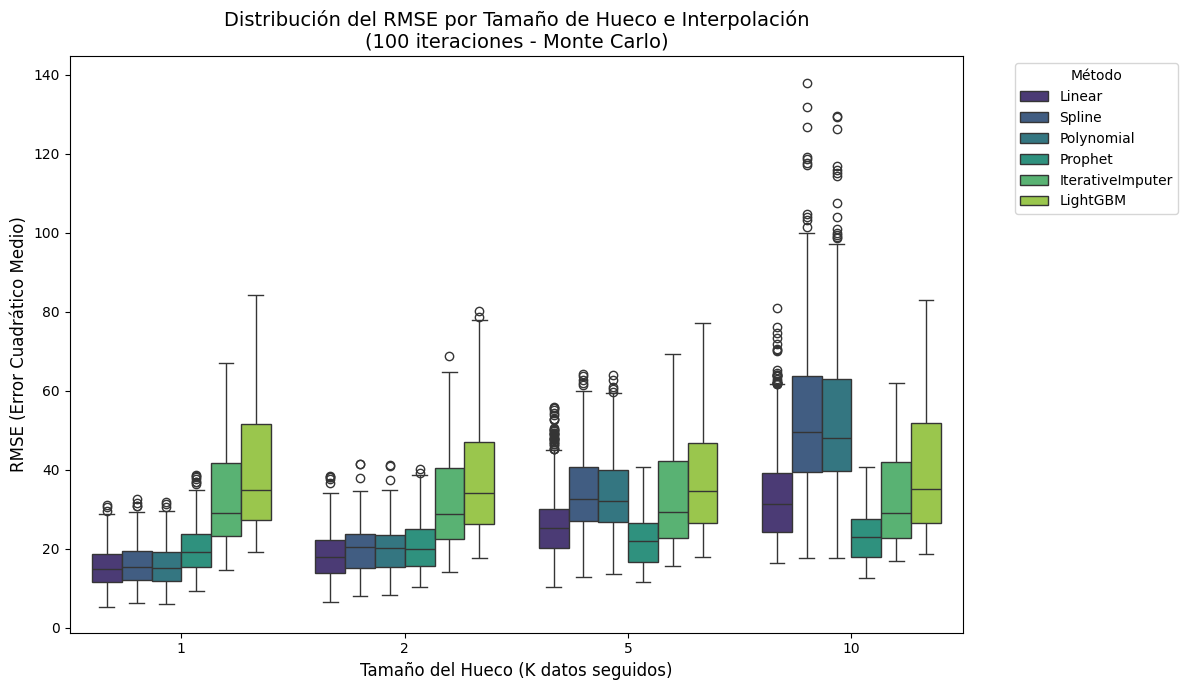

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Configuración de estilo
#sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

# Generación del Boxplot
# Usamos df_benchmark porque contiene todas las iteraciones (no el df_final_stats)
ax = sns.boxplot(
    data=df_benchmark, 
    x='Size_K', 
    y='RMSE', 
    hue='Method',
    palette='viridis',
    showfliers=True
)

# Personalización de ejes y títulos
plt.title('Distribución del RMSE por Tamaño de Hueco e Interpolación\n(100 iteraciones - Monte Carlo)', fontsize=14)
plt.xlabel('Tamaño del Hueco (K datos seguidos)', fontsize=12)
plt.ylabel('RMSE (Error Cuadrático Medio)', fontsize=12)
plt.legend(title='Método', bbox_to_anchor=(1.05, 1), loc='upper left')


plt.tight_layout()
plt.show()

In [ ]:
# Comparación global simple
ranking = (
    df_benchmark
    .groupby(['Method', 'Size_K'])['RMSE']
    .mean()
    .reset_index()
)

ranking['Rank'] = ranking.groupby('Size_K')['RMSE']\
                          .rank(method='average')

print(ranking.sort_values(['Size_K','Rank']))

In [ ]:
# Ranking promedio global
ranking_global = (
    ranking
    .groupby('Method')['Rank']
    .mean()
    .reset_index()
    .sort_values('Rank')
)

print(ranking_global)


In [ ]:
# Considerar estabilidad
estabilidad = (
    df_benchmark
    .groupby(['Method', 'Size_K'])['RMSE']
    .std()
    .reset_index()
)

# score combinado penaliza métodos inestables
resumen = (
    df_benchmark
    .groupby(['Method', 'Size_K'])['RMSE']
    .agg(['mean','std'])
    .reset_index()
)

resumen['Score'] = resumen['mean'] + resumen['std']
resumen = resumen.sort_values(by=['Size_K', 'Score'], ascending=[True, True])

top_metodos = resumen.groupby('Size_K').head(3)

print("--- Ranking de Métodos por Tamaño de Hueco (K) ---")
print(top_metodos.to_string(index=False))


In [16]:
from scipy.stats import friedmanchisquare

# Crear matriz método x escenario
pivot = (
    df_benchmark
    .groupby(['Method','Series','Size_K'])['RMSE']
    .mean()
    .reset_index()
    .pivot_table(index=['Series','Size_K'],
                 columns='Method',
                 values='RMSE')
)

friedmanchisquare(*[pivot[col] for col in pivot.columns])# Si el p-valor < 0.05 existen diferencias significativas.

FriedmanchisquareResult(statistic=np.float64(94.85714285714278), pvalue=np.float64(6.399092741458015e-19))